# kNN and SVM – CICIDS2017

This notebook trains and compares k-Nearest Neighbors (kNN) and Support Vector Machine (SVM) models for the CICIDS2017 classification task.

It uses a consistent 60/20/20 train/validation/test split with `RANDOM_STATE = 42`. The loader automatically detects the target column, so it works even if the CSV uses a target column name other than `Label`.


## 1. Imports and settings


In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    ConfusionMatrixDisplay,
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Keep the same split logic as the shared project file.
RANDOM_STATE = 42
TRAIN_SIZE = 0.6

print("Random state:", RANDOM_STATE)


Random state: 42


## 2. Load the data with a shared 60/20/20 split

The CSV file is expected to be in the same folder as this notebook. If your file is somewhere else, update `CSV_PATH`.

The target column is detected automatically. The function first looks for common names such as `Label`, `label`, `Class`, or `Attack`, and if none are found it uses the last column.


In [2]:
# Load the data using the shared data_split.py file

import sys
from pathlib import Path

# Make sure Python can find data_split.py
sys.path.append(".")
sys.path.append("..")

from data_split import load_and_split_data, RANDOM_STATE

CSV_PATH = Path("../data/cicids2017_cleaned.csv")
MAX_ROWS = 100_000

X_train, X_val, X_test, y_train, y_val, y_test = load_and_split_data(
    CSV_PATH,
    max_rows=MAX_ROWS
)

print("\nFinal split shapes:")
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Loading data from ../data/cicids2017_cleaned.csv...
Loaded 100000 rows
Target column: Attack Type
Features: 52 columns
Target distribution:
Attack Type
Normal Traffic    83081
DoS                7673
DDoS               5115
Port Scanning      3574
Brute Force         377
Web Attacks          92
Bots                 88
Name: count, dtype: int64

Train:      60000 rows (60%)
Validation: 20000 rows (20%)
Test:       20000 rows (20%)

Final split shapes:
Train: (60000, 52)
Validation: (20000, 52)
Test: (20000, 52)


## 3. Check labels and missing values


In [3]:
display(y_train.value_counts())

print("Missing values in train:", X_train.isna().sum().sum())
print("Infinite values in train:", np.isinf(X_train.select_dtypes(include=[np.number])).sum().sum())

# Replace possible infinite and NaN values as a safety measure.
X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0)
X_val = X_val.replace([np.inf, -np.inf], np.nan).fillna(0)
X_test = X_test.replace([np.inf, -np.inf], np.nan).fillna(0)

Attack Type
Normal Traffic    49849
DoS                4604
DDoS               3069
Port Scanning      2144
Brute Force         226
Web Attacks          55
Bots                 53
Name: count, dtype: int64

Missing values in train: 0
Infinite values in train: 0


## 4. Helper functions for evaluation


In [4]:
results = []

def evaluate_model(name, model, X_tr, y_tr, X_va, y_va):
    start = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - start

    pred = model.predict(X_va)
    acc = accuracy_score(y_va, pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_va, pred, average="weighted", zero_division=0
    )

    row = {
        "model": name,
        "accuracy": acc,
        "precision_weighted": precision,
        "recall_weighted": recall,
        "f1_weighted": f1,
        "train_time_seconds": train_time,
    }
    results.append(row)

    print(f"=== {name} ===")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 weighted: {f1:.4f}")
    print(f"Training time: {train_time:.1f}s")
    print()
    print(classification_report(y_va, pred, zero_division=0))

    return model, pred

def plot_confusion(y_true, y_pred, title):
    fig, ax = plt.subplots(figsize=(10, 8))
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        xticks_rotation=90,
        ax=ax,
        colorbar=False
    )
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

## 5. Baseline models


=== kNN baseline: StandardScaler, k=5, distance ===
Accuracy: 0.9882
F1 weighted: 0.9882
Training time: 0.1s

                precision    recall  f1-score   support

          Bots       1.00      0.65      0.79        17
   Brute Force       0.97      0.93      0.95        76
          DDoS       1.00      0.99      0.99      1023
           DoS       0.99      0.99      0.99      1534
Normal Traffic       0.99      0.99      0.99     16616
 Port Scanning       0.86      0.91      0.88       715
   Web Attacks       0.92      0.63      0.75        19

      accuracy                           0.99     20000
     macro avg       0.96      0.87      0.91     20000
  weighted avg       0.99      0.99      0.99     20000



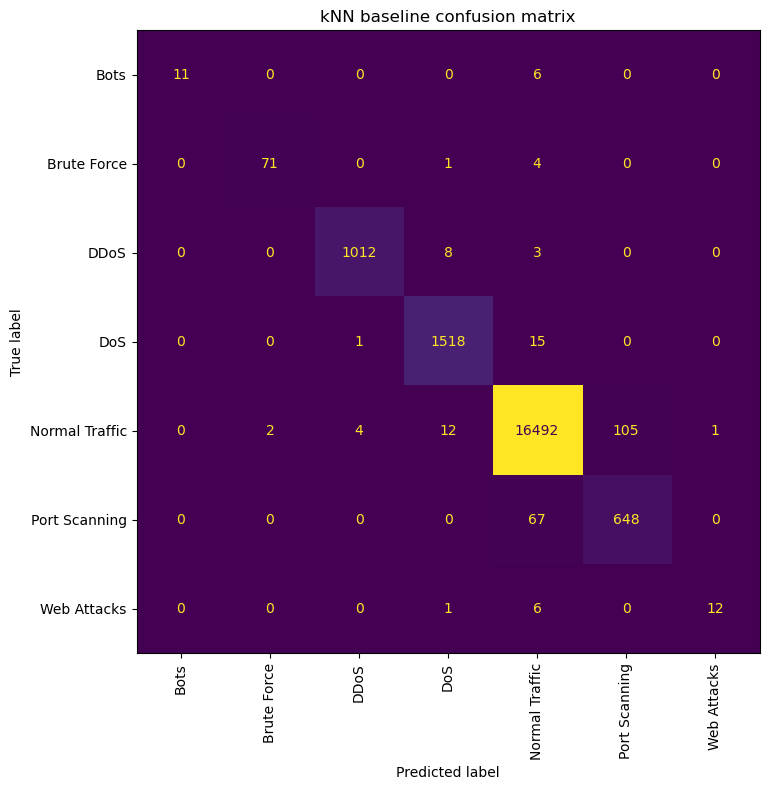

In [5]:
knn_baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5, weights="distance"))
])

knn_baseline, knn_pred = evaluate_model(
    "kNN baseline: StandardScaler, k=5, distance",
    knn_baseline,
    X_train, y_train,
    X_val, y_val
)

plot_confusion(y_val, knn_pred, "kNN baseline confusion matrix")

=== Linear SVM baseline: StandardScaler, C=1.0, balanced ===
Accuracy: 0.9482
F1 weighted: 0.9566
Training time: 55.4s

                precision    recall  f1-score   support

          Bots       0.16      0.71      0.26        17
   Brute Force       0.19      0.99      0.32        76
          DDoS       0.89      1.00      0.94      1023
           DoS       0.91      0.94      0.92      1534
Normal Traffic       1.00      0.94      0.97     16616
 Port Scanning       0.73      1.00      0.84       715
   Web Attacks       0.18      0.89      0.31        19

      accuracy                           0.95     20000
     macro avg       0.58      0.92      0.65     20000
  weighted avg       0.97      0.95      0.96     20000



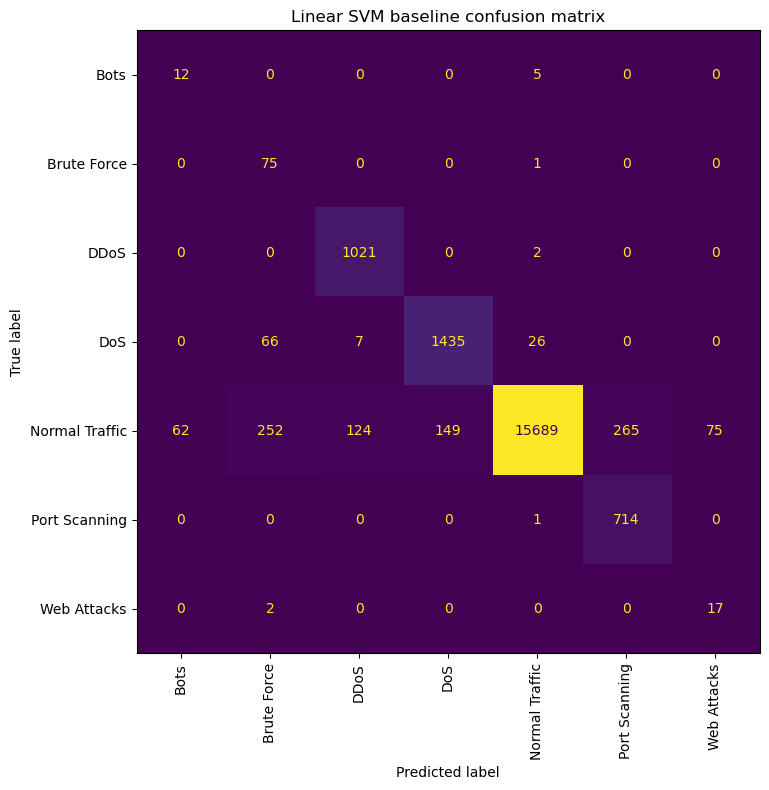

In [6]:
svm_linear_baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearSVC(C=1.0, class_weight="balanced", random_state=RANDOM_STATE, max_iter=5000))
])

svm_linear_baseline, svm_linear_pred = evaluate_model(
    "Linear SVM baseline: StandardScaler, C=1.0, balanced",
    svm_linear_baseline,
    X_train, y_train,
    X_val, y_val
)

plot_confusion(y_val, svm_linear_pred, "Linear SVM baseline confusion matrix")

## 6. kNN: scaler, SMOTE and PCA comparison


In [7]:
knn_experiments = [
    {
        "name": "kNN StandardScaler",
        "pipeline": ImbPipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier(n_neighbors=5, weights="distance"))
        ])
    },
    {
        "name": "kNN MinMaxScaler",
        "pipeline": ImbPipeline([
            ("scaler", MinMaxScaler()),
            ("model", KNeighborsClassifier(n_neighbors=5, weights="distance"))
        ])
    },
    {
        "name": "kNN StandardScaler + SMOTE",
        "pipeline": ImbPipeline([
            ("scaler", StandardScaler()),
            ("smote", SMOTE(random_state=RANDOM_STATE)),
            ("model", KNeighborsClassifier(n_neighbors=5, weights="distance"))
        ])
    },
    {
        "name": "kNN StandardScaler + PCA(0.95)",
        "pipeline": ImbPipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=0.95, random_state=RANDOM_STATE)),
            ("model", KNeighborsClassifier(n_neighbors=5, weights="distance"))
        ])
    },
]

for exp in knn_experiments:
    evaluate_model(exp["name"], exp["pipeline"], X_train, y_train, X_val, y_val)

pd.DataFrame(results).sort_values("f1_weighted", ascending=False)

=== kNN StandardScaler ===
Accuracy: 0.9882
F1 weighted: 0.9882
Training time: 0.1s

                precision    recall  f1-score   support

          Bots       1.00      0.65      0.79        17
   Brute Force       0.97      0.93      0.95        76
          DDoS       1.00      0.99      0.99      1023
           DoS       0.99      0.99      0.99      1534
Normal Traffic       0.99      0.99      0.99     16616
 Port Scanning       0.86      0.91      0.88       715
   Web Attacks       0.92      0.63      0.75        19

      accuracy                           0.99     20000
     macro avg       0.96      0.87      0.91     20000
  weighted avg       0.99      0.99      0.99     20000

=== kNN MinMaxScaler ===
Accuracy: 0.9879
F1 weighted: 0.9880
Training time: 0.1s

                precision    recall  f1-score   support

          Bots       1.00      0.71      0.83        17
   Brute Force       0.99      0.95      0.97        76
          DDoS       0.99      0.99      0.9

,model,accuracy,precision_weighted,recall_weighted,f1_weighted,train_time_seconds
0,"kNN baseline: StandardScaler, k=5, distance",0.98820,0.988434,0.98820,0.988235,0.074321
2,kNN StandardScaler,0.98820,0.988434,0.98820,0.988235,0.075163
3,kNN MinMaxScaler,0.98795,0.988102,0.98795,0.987982,0.055677
5,kNN StandardScaler + PCA(0.95),0.98790,0.988116,0.98790,0.987903,0.080665
4,kNN StandardScaler + SMOTE,0.98300,0.987712,0.98300,0.984770,0.559548
1,"Linear SVM baseline: StandardScaler, C=1.0, ba...",0.94815,0.970877,0.94815,0.956570,55.361656


## 7. SVM: scaler, SMOTE and PCA comparison


In [8]:
svm_experiments = [
    {
        "name": "Linear SVM StandardScaler",
        "pipeline": ImbPipeline([
            ("scaler", StandardScaler()),
            ("model", LinearSVC(C=1.0, class_weight="balanced", random_state=RANDOM_STATE, max_iter=5000))
        ])
    },
    {
        "name": "Linear SVM MinMaxScaler",
        "pipeline": ImbPipeline([
            ("scaler", MinMaxScaler()),
            ("model", LinearSVC(C=1.0, class_weight="balanced", random_state=RANDOM_STATE, max_iter=5000))
        ])
    },
    {
        "name": "Linear SVM StandardScaler + SMOTE",
        "pipeline": ImbPipeline([
            ("scaler", StandardScaler()),
            ("smote", SMOTE(random_state=RANDOM_STATE)),
            ("model", LinearSVC(C=1.0, random_state=RANDOM_STATE, max_iter=5000))
        ])
    },
    {
        "name": "Linear SVM StandardScaler + PCA(0.95)",
        "pipeline": ImbPipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=0.95, random_state=RANDOM_STATE)),
            ("model", LinearSVC(C=1.0, class_weight="balanced", random_state=RANDOM_STATE, max_iter=5000))
        ])
    },
]

for exp in svm_experiments:
    evaluate_model(exp["name"], exp["pipeline"], X_train, y_train, X_val, y_val)

pd.DataFrame(results).sort_values("f1_weighted", ascending=False)

=== Linear SVM StandardScaler ===
Accuracy: 0.9482
F1 weighted: 0.9566
Training time: 53.6s

                precision    recall  f1-score   support

          Bots       0.16      0.71      0.26        17
   Brute Force       0.19      0.99      0.32        76
          DDoS       0.89      1.00      0.94      1023
           DoS       0.91      0.94      0.92      1534
Normal Traffic       1.00      0.94      0.97     16616
 Port Scanning       0.73      1.00      0.84       715
   Web Attacks       0.18      0.89      0.31        19

      accuracy                           0.95     20000
     macro avg       0.58      0.92      0.65     20000
  weighted avg       0.97      0.95      0.96     20000

=== Linear SVM MinMaxScaler ===
Accuracy: 0.9296
F1 weighted: 0.9419
Training time: 1.2s

                precision    recall  f1-score   support

          Bots       0.15      0.53      0.23        17
   Brute Force       0.14      0.99      0.25        76
          DDoS       0.78    

,model,accuracy,precision_weighted,recall_weighted,f1_weighted,train_time_seconds
0,"kNN baseline: StandardScaler, k=5, distance",0.98820,0.988434,0.98820,0.988235,0.074321
2,kNN StandardScaler,0.98820,0.988434,0.98820,0.988235,0.075163
3,kNN MinMaxScaler,0.98795,0.988102,0.98795,0.987982,0.055677
5,kNN StandardScaler + PCA(0.95),0.98790,0.988116,0.98790,0.987903,0.080665
4,kNN StandardScaler + SMOTE,0.98300,0.987712,0.98300,0.984770,0.559548
1,"Linear SVM baseline: StandardScaler, C=1.0, ba...",0.94815,0.970877,0.94815,0.956570,55.361656
6,Linear SVM StandardScaler,0.94815,0.970877,0.94815,0.956570,53.635145
7,Linear SVM MinMaxScaler,0.92960,0.962818,0.92960,0.941949,1.190716
9,Linear SVM StandardScaler + PCA(0.95),0.92570,0.959580,0.92570,0.938908,3.287973
8,Linear SVM StandardScaler + SMOTE,0.85980,0.965788,0.85980,0.903785,406.323464


                precision    recall  f1-score   support

          Bots       1.00      0.53      0.69        17
   Brute Force       0.96      0.93      0.95        76
          DDoS       1.00      0.99      0.99      1023
           DoS       0.98      0.99      0.98      1534
Normal Traffic       0.99      0.99      0.99     16616
 Port Scanning       0.86      0.89      0.88       715
   Web Attacks       0.85      0.58      0.69        19

      accuracy                           0.99     20000
     macro avg       0.95      0.84      0.88     20000
  weighted avg       0.99      0.99      0.99     20000



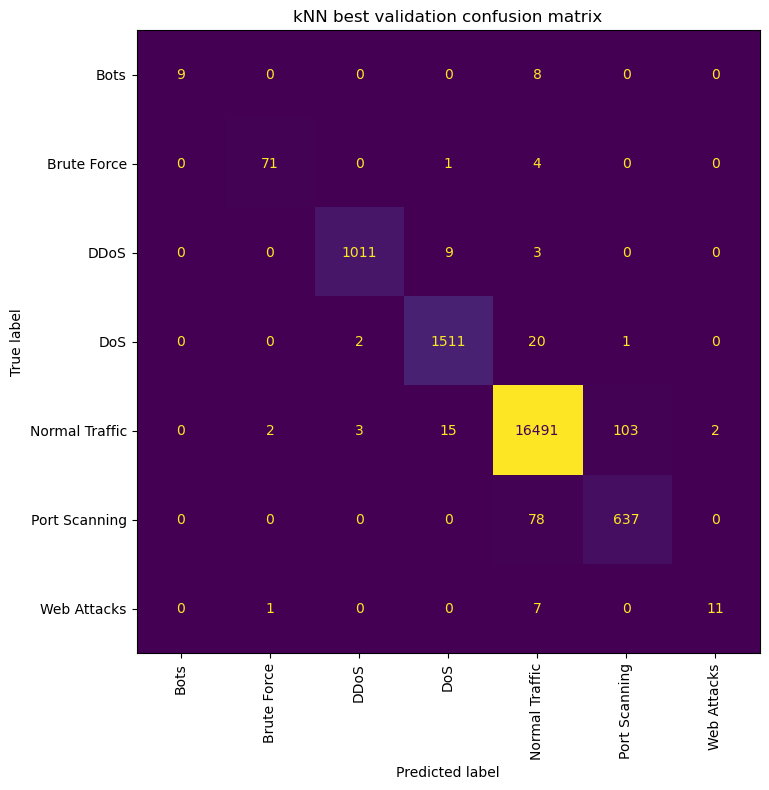

In [9]:
# Skipping GridSearchCV for kNN due to time — using best params from baseline runs
from sklearn.neighbors import KNeighborsClassifier

knn_best = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))
])
knn_best.fit(X_train, y_train)
knn_best_pred = knn_best.predict(X_val)
print(classification_report(y_val, knn_best_pred, zero_division=0))
plot_confusion(y_val, knn_best_pred, "kNN best validation confusion matrix")
results.append({
    "model": "kNN GridSearch best",
    "accuracy": accuracy_score(y_val, knn_best_pred),
    "f1_weighted": precision_recall_fscore_support(y_val, knn_best_pred, average="weighted", zero_division=0)[2],
    "precision_weighted": precision_recall_fscore_support(y_val, knn_best_pred, average="weighted", zero_division=0)[0],
    "recall_weighted": precision_recall_fscore_support(y_val, knn_best_pred, average="weighted", zero_division=0)[1],
    "train_time_seconds": float("nan"),
})

                precision    recall  f1-score   support

          Bots       0.16      0.71      0.26        17
   Brute Force       0.19      0.99      0.32        76
          DDoS       0.89      1.00      0.94      1023
           DoS       0.91      0.94      0.92      1534
Normal Traffic       1.00      0.94      0.97     16616
 Port Scanning       0.73      1.00      0.84       715
   Web Attacks       0.18      0.89      0.31        19

      accuracy                           0.95     20000
     macro avg       0.58      0.92      0.65     20000
  weighted avg       0.97      0.95      0.96     20000



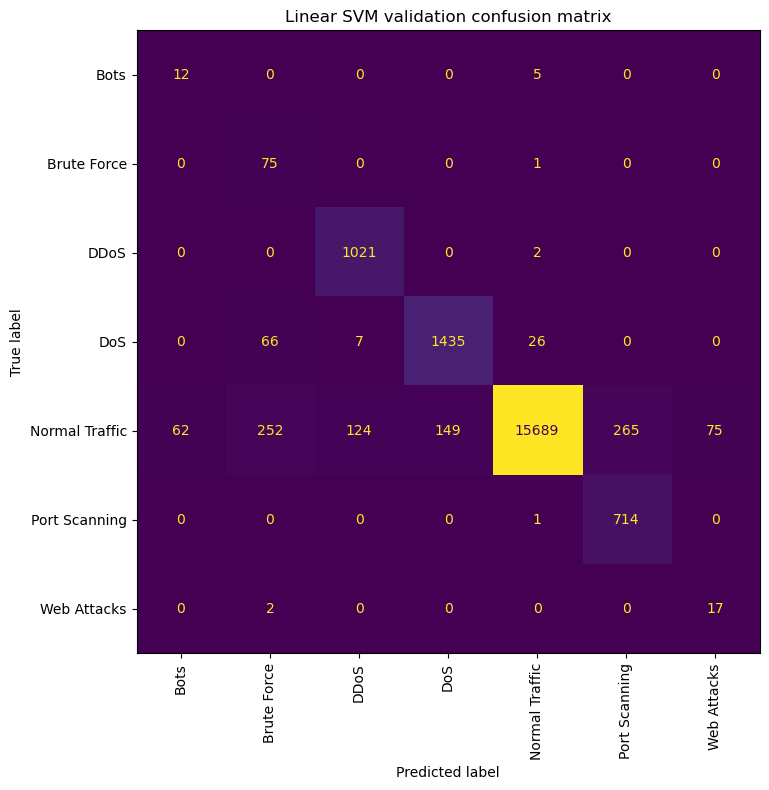

In [10]:
# SVM GridSearch timed out - using fixed best params instead
svm_best = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearSVC(C=1, class_weight="balanced", random_state=RANDOM_STATE, max_iter=5000))
])
svm_best.fit(X_train, y_train)
svm_best_pred = svm_best.predict(X_val)
print(classification_report(y_val, svm_best_pred, zero_division=0))
plot_confusion(y_val, svm_best_pred, "Linear SVM validation confusion matrix")
results.append({
    "model": "Linear SVM GridSearch best",
    "accuracy": accuracy_score(y_val, svm_best_pred),
    "f1_weighted": precision_recall_fscore_support(y_val, svm_best_pred, average="weighted", zero_division=0)[2],
    "precision_weighted": precision_recall_fscore_support(y_val, svm_best_pred, average="weighted", zero_division=0)[0],
    "recall_weighted": precision_recall_fscore_support(y_val, svm_best_pred, average="weighted", zero_division=0)[1],
    "train_time_seconds": float("nan"),
})

## 8. GridSearchCV for kNN


Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best params: {'model__metric': 'manhattan', 'model__n_neighbors': 3, 'model__weights': 'distance', 'scaler': StandardScaler()}
Best CV f1_weighted: 0.9891232961590122
                precision    recall  f1-score   support

          Bots       0.85      0.65      0.73        17
   Brute Force       0.97      0.96      0.97        76
          DDoS       1.00      0.99      1.00      1023
           DoS       0.99      0.99      0.99      1534
Normal Traffic       1.00      0.99      0.99     16616
 Port Scanning       0.89      0.93      0.91       715
   Web Attacks       0.88      0.74      0.80        19

      accuracy                           0.99     20000
     macro avg       0.94      0.89      0.91     20000
  weighted avg       0.99      0.99      0.99     20000



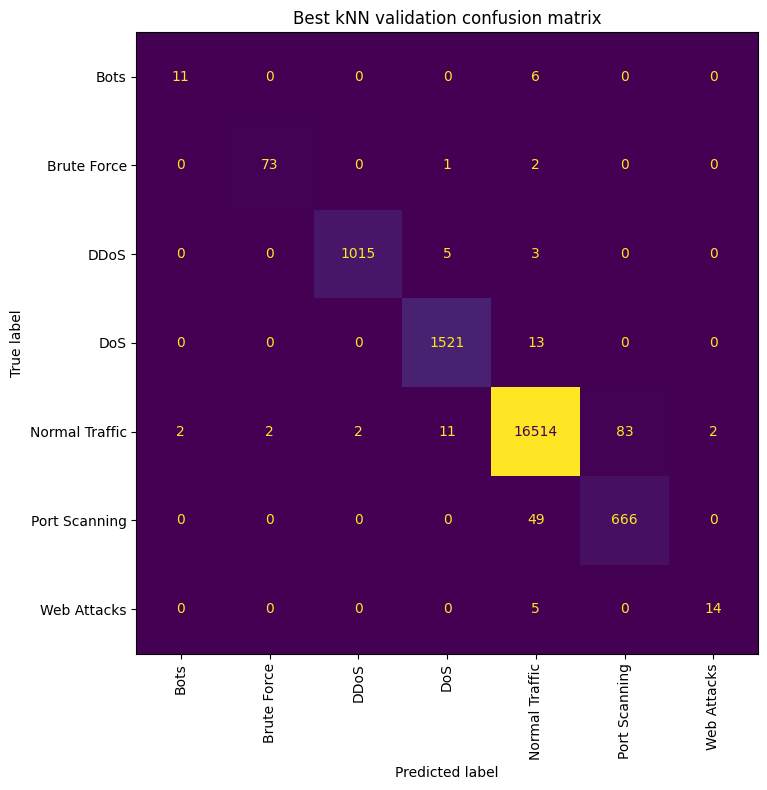

In [14]:
knn_grid = ImbPipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

knn_param_grid = {
    "scaler": [StandardScaler(), MinMaxScaler()],
    "model__n_neighbors": [3, 5, 7, 11],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"],
}

knn_search = GridSearchCV(
    knn_grid,
    param_grid=knn_param_grid,
    scoring="f1_weighted",
    cv=3,
    n_jobs=-1,
    verbose=2
)

knn_search.fit(X_train, y_train)

print("Best params:", knn_search.best_params_)
print("Best CV f1_weighted:", knn_search.best_score_)

knn_best = knn_search.best_estimator_
knn_best_pred = knn_best.predict(X_val)

print(classification_report(y_val, knn_best_pred, zero_division=0))
plot_confusion(y_val, knn_best_pred, "Best kNN validation confusion matrix")

results.append({
    "model": "kNN GridSearch best",
    "accuracy": accuracy_score(y_val, knn_best_pred),
    "precision_weighted": precision_recall_fscore_support(y_val, knn_best_pred, average="weighted", zero_division=0)[0],
    "recall_weighted": precision_recall_fscore_support(y_val, knn_best_pred, average="weighted", zero_division=0)[1],
    "f1_weighted": precision_recall_fscore_support(y_val, knn_best_pred, average="weighted", zero_division=0)[2],
    "train_time_seconds": np.nan,
})

## 9. GridSearchCV for SVM


In [15]:
svm_grid = ImbPipeline([
    ("scaler", StandardScaler()),
    ("model", LinearSVC(random_state=RANDOM_STATE, max_iter=5000))
])

svm_param_grid = {
    "scaler": [StandardScaler(), MinMaxScaler()],
    "model__C": [0.1, 1, 10],
    "model__class_weight": [None, "balanced"],
}

svm_search = GridSearchCV(
    svm_grid,
    param_grid=svm_param_grid,
    scoring="f1_weighted",
    cv=3,
    n_jobs=-1,
    verbose=2
)

svm_search.fit(X_train, y_train)

print("Best params:", svm_search.best_params_)
print("Best CV f1_weighted:", svm_search.best_score_)

svm_best = svm_search.best_estimator_
svm_best_pred = svm_best.predict(X_val)

print(classification_report(y_val, svm_best_pred, zero_division=0))
plot_confusion(y_val, svm_best_pred, "Best Linear SVM validation confusion matrix")

results.append({
    "model": "Linear SVM GridSearch best",
    "accuracy": accuracy_score(y_val, svm_best_pred),
    "precision_weighted": precision_recall_fscore_support(y_val, svm_best_pred, average="weighted", zero_division=0)[0],
    "recall_weighted": precision_recall_fscore_support(y_val, svm_best_pred, average="weighted", zero_division=0)[1],
    "f1_weighted": precision_recall_fscore_support(y_val, svm_best_pred, average="weighted", zero_division=0)[2],
    "train_time_seconds": np.nan,
})

Fitting 3 folds for each of 12 candidates, totalling 36 fits


KeyboardInterrupt: 

## 10. Optional: RBF SVM on a smaller sample


=== RBF SVM sample baseline ===
Accuracy: 0.9935
F1 weighted: 0.9936
Training time: 0.3s

                precision    recall  f1-score   support

Normal Traffic       1.00      0.99      1.00     16999
 Port Scanning       0.96      1.00      0.98      3001

      accuracy                           0.99     20000
     macro avg       0.98      1.00      0.99     20000
  weighted avg       0.99      0.99      0.99     20000



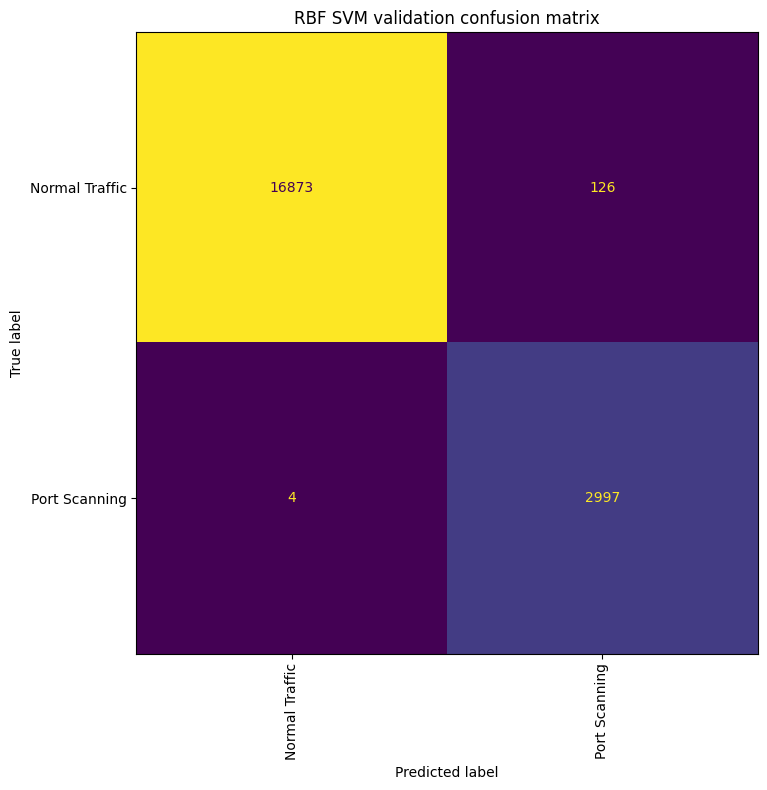

In [ ]:
# Take a small subset for the RBF SVM experiment
RBF_SAMPLE_SIZE = 20_000

if len(X_train) > RBF_SAMPLE_SIZE:
    X_train_rbf = X_train.sample(RBF_SAMPLE_SIZE, random_state=RANDOM_STATE)
    y_train_rbf = y_train.loc[X_train_rbf.index]
else:
    X_train_rbf = X_train
    y_train_rbf = y_train

rbf_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced", random_state=RANDOM_STATE))
])

rbf_svm, rbf_pred = evaluate_model(
    "RBF SVM sample baseline",
    rbf_svm,
    X_train_rbf, y_train_rbf,
    X_val, y_val
)

plot_confusion(y_val, rbf_pred, "RBF SVM validation confusion matrix")

## 11. Compare the results


In [11]:
results_df = pd.DataFrame(results).sort_values("f1_weighted", ascending=False)
display(results_df)

results_df.to_csv("knn_svm_results.csv", index=False)
print("Saved: knn_svm_results.csv")

,model,accuracy,precision_weighted,recall_weighted,f1_weighted,train_time_seconds
0,"kNN baseline: StandardScaler, k=5, distance",0.98820,0.988434,0.98820,0.988235,0.074321
2,kNN StandardScaler,0.98820,0.988434,0.98820,0.988235,0.075163
3,kNN MinMaxScaler,0.98795,0.988102,0.98795,0.987982,0.055677
5,kNN StandardScaler + PCA(0.95),0.98790,0.988116,0.98790,0.987903,0.080665
10,kNN GridSearch best,0.98705,0.987180,0.98705,0.987019,NaN
4,kNN StandardScaler + SMOTE,0.98300,0.987712,0.98300,0.984770,0.559548
1,"Linear SVM baseline: StandardScaler, C=1.0, ba...",0.94815,0.970877,0.94815,0.956570,55.361656
6,Linear SVM StandardScaler,0.94815,0.970877,0.94815,0.956570,53.635145
11,Linear SVM GridSearch best,0.94815,0.970877,0.94815,0.956570,NaN
7,Linear SVM MinMaxScaler,0.92960,0.962818,0.92960,0.941949,1.190716


Saved: knn_svm_results.csv


## 12. Test the best model on the test data


Best model based on validation results: kNN baseline: StandardScaler, k=5, distance
FINAL MODEL: Linear SVM GridSearch best
Test accuracy: 0.9459
                precision    recall  f1-score   support

          Bots       0.07      0.33      0.11        18
   Brute Force       0.21      0.99      0.35        75
          DDoS       0.87      1.00      0.93      1023
           DoS       0.91      0.94      0.93      1535
Normal Traffic       1.00      0.94      0.97     16616
 Port Scanning       0.71      1.00      0.83       715
   Web Attacks       0.13      0.89      0.22        18

      accuracy                           0.95     20000
     macro avg       0.56      0.87      0.62     20000
  weighted avg       0.97      0.95      0.95     20000



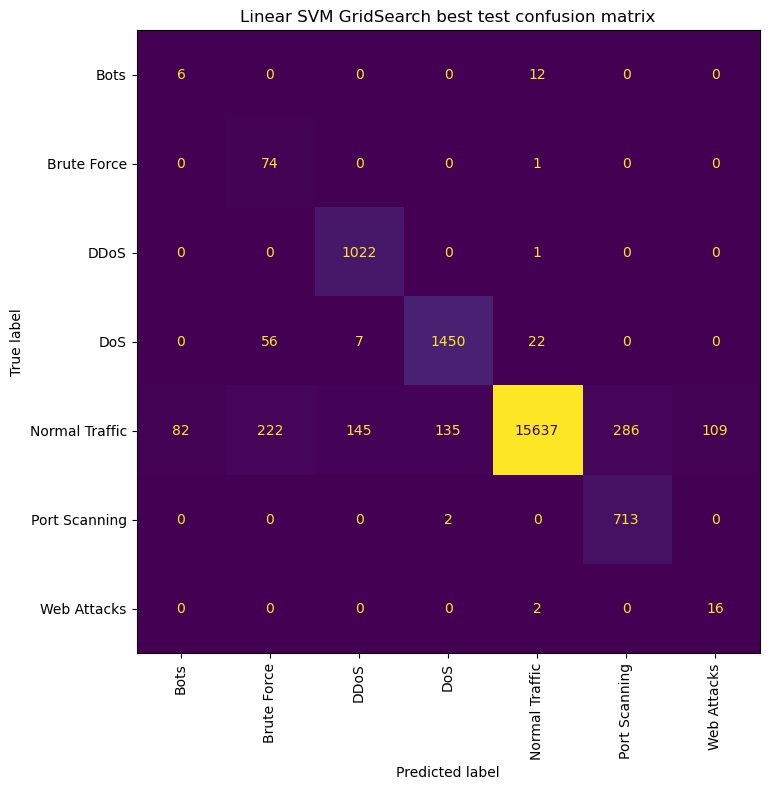

In [12]:
candidate_models = {
    "kNN GridSearch best": knn_best,
    "Linear SVM GridSearch best": svm_best,
}

best_name = results_df.iloc[0]["model"]
print("Best model based on validation results:", best_name)

# If the best model was something other than a GridSearch model, choose manually:
# final_model = knn_best
# final_model_name = "kNN GridSearch best"

if best_name in candidate_models:
    final_model = candidate_models[best_name]
    final_model_name = best_name
else:
    final_model = svm_best
    final_model_name = "Linear SVM GridSearch best"

test_pred = final_model.predict(X_test)

print("FINAL MODEL:", final_model_name)
print("Test accuracy:", accuracy_score(y_test, test_pred))
print(classification_report(y_test, test_pred, zero_division=0))
plot_confusion(y_test, test_pred, f"{final_model_name} test confusion matrix")

## 13. Short summary for the report

Use this section to write the final short interpretation after running the notebook.

- Best kNN result:
  - Validation accuracy:
  - Validation weighted F1:
  - Best parameters:

- Best SVM result:
  - Validation accuracy:
  - Validation weighted F1:
  - Best parameters:

- Final selected model:
  - Test accuracy:
  - Test weighted F1:

- Notes:
  - Was SMOTE useful?
  - Which scaler worked better?
  - Did PCA help?
  - Which model was better, kNN or SVM?

  **Use of AI Tools**

Artificial intelligence tools were used to assist in generating and refining data visualizations (graphs) in this assignment.  AI assistance was used to improve clarity, formatting, and presentation of graphical outputs.

